In [4]:
from preprocess import get_time_series_data


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/husted42/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Loaded 2640 tweets from ../trumpData/realDonaldTrump_truths_2.json


[*********************100%***********************]  1 of 1 completed


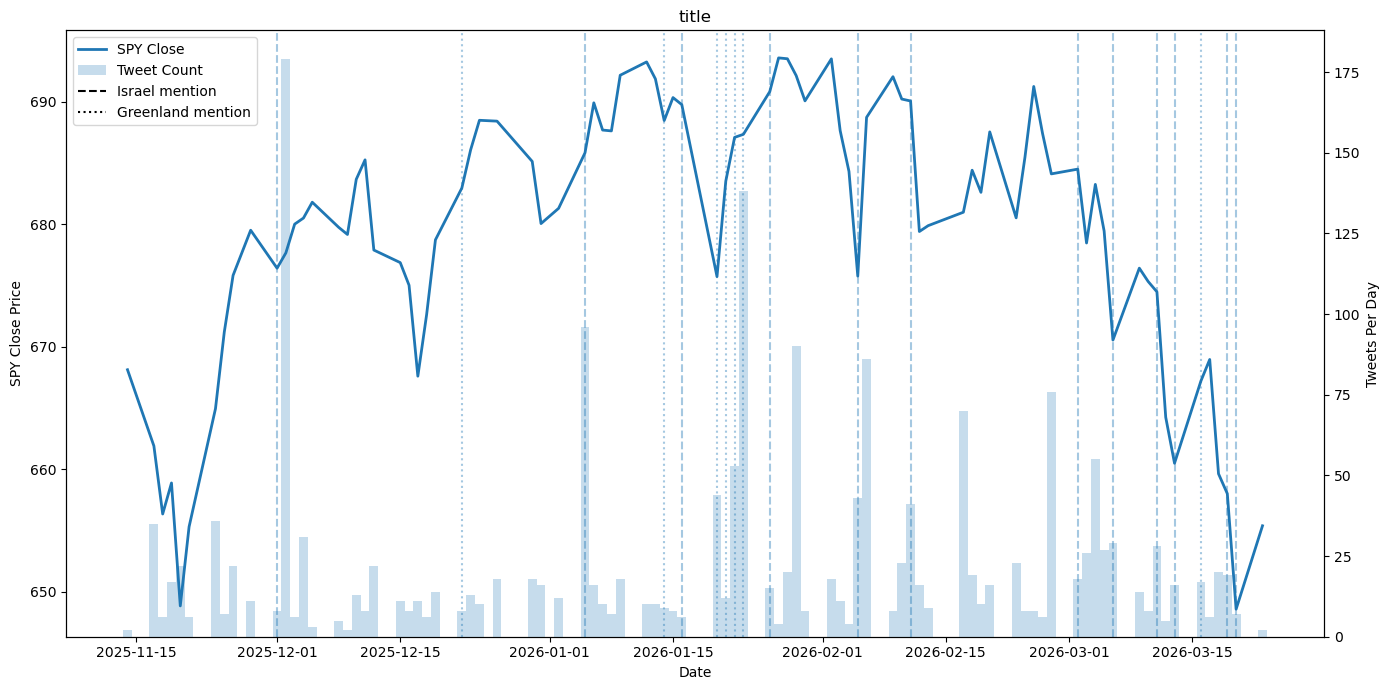

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

FILE_PATH = "../trumpData/realDonaldTrump_truths_2.json"

df = get_time_series_data(FILE_PATH, 'SPY', 6)

plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.sort_values("date")

fig, ax1 = plt.subplots(figsize=(14, 7))

# Price line
ax1.plot(plot_df["date"], plot_df["price"], linewidth=2, label="SPY Close")
ax1.set_xlabel("Date")
ax1.set_ylabel("SPY Close Price")
ax1.set_title("Mega cool plot 😎")

# Tweet count bars on second axis
ax2 = ax1.twinx()
ax2.bar(plot_df["date"], plot_df["tweet_count"], alpha=0.25, width=1.0, label="Tweet Count")
ax2.set_ylabel("Tweets Per Day")

# Keyword event markers
israel_dates = plot_df.loc[plot_df["mention_israel"] == 1, "date"]
greenland_dates = plot_df.loc[plot_df["mention_greenland"] == 1, "date"]

for d in israel_dates:
    ax1.axvline(d, linestyle="--", alpha=0.4)

for d in greenland_dates:
    ax1.axvline(d, linestyle=":", alpha=0.4)

# Legend including mention markers
proxy_israel = Line2D([0], [0], color='black', linestyle='--', label='Israel mention')
proxy_greenland = Line2D([0], [0], color='black', linestyle=':', label='Greenland mention')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + [proxy_israel, proxy_greenland],
           labels_1 + labels_2 + ['Israel mention', 'Greenland mention'],
           loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()